# Support vector machines. A polar coordinates approach (experimentation).

## The plan

Given a set of data points $\left\{\begin{pmatrix} x_1 \\ x_2 \end{pmatrix} \in \mathbb{R}^2 \right\}$, along with a label $y \in \{\pm1\}$ we investigate a polar coordinate approach to finding the optimal hyperplane (in the 2D case, a line). 

To do this, we consider the unit vector $w_\theta = \begin{pmatrix} \cos(\theta) \\ \sin(\theta) \end{pmatrix}$ along with corresponding orthogonal vector $n_\theta = \begin{pmatrix} -\sin(\theta) \\ \cos(\theta) \end{pmatrix}$ for each $\theta \in [0,2\pi)$.

For each $\theta$, we write each data point $\mathbf{x}_i = (x_1,x_2)$ with respect to the basis vectors $\{w_\theta, n_\theta\}$, say $\mathbf{x}_i = \alpha_i w_\theta + \beta_i n_\theta$, where 
$$\begin{pmatrix} \alpha_i \\ \beta_i \end{pmatrix} = \begin{pmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{pmatrix}^{-1}\begin{pmatrix} x_1 \\ x_2 \end{pmatrix} = \begin{pmatrix} \cos(\theta) & \sin(\theta) \\ -\sin(\theta) & \cos(\theta) \end{pmatrix}\begin{pmatrix} x_1 \\ x_2 \end{pmatrix}.$$ 
Then the width of the "street" will be $r_\theta := \min\{\alpha_i : y_i = +1\} - \max\{\alpha_i : y_i = -1\}$. This idea is illustrated in the following diagram:

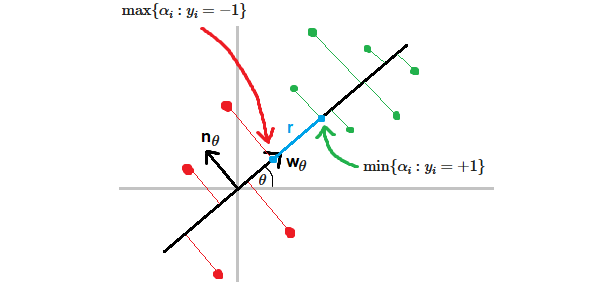

Then, we choose $\theta$ such that $r_\theta$ is maximised. 

Then, the required hyperplane (line) is given by $\langle w_\theta, x \rangle = C$, where $C$ is the midpoint between $\min\{\alpha_i : y_i = +1\}$ and $\max\{\alpha_i : y_i = -1\}$. 

That is, $C := \frac{1}{2}(\min\{\alpha_i : y_i = +1\} + \max\{\alpha_i : y_i = -1\})$.

## Generating some data 

We generate data such that the negative points lie below the line $y = -\frac{1}{2}x + 3$, and the positive points lie above $y = -\frac{1}{2}x + 6$. These lines are as follows.

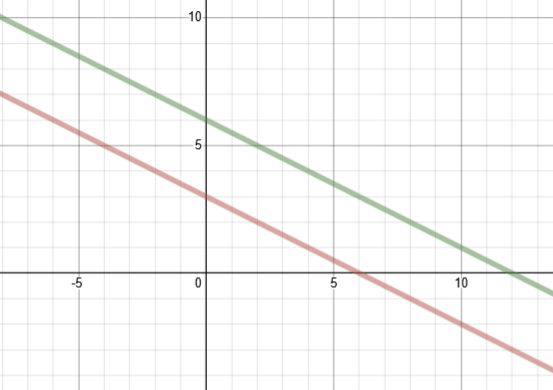

For a general sample of generated points, we expect the optimal $\theta$ to be around $\arctan(2) \approx 63.43^\circ$, and $C$ to be approximately $\left|\left|\begin{pmatrix} 1.8 \\ 3.6 \end{pmatrix}\right|\right| \approx 4.025$. 

That is, $C$ should be approximately the distance from the origin to the point on the line $y = \tan(\arctan(2))x = 2x$ that lies midway between the green and red lines in the above diagram.

In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize

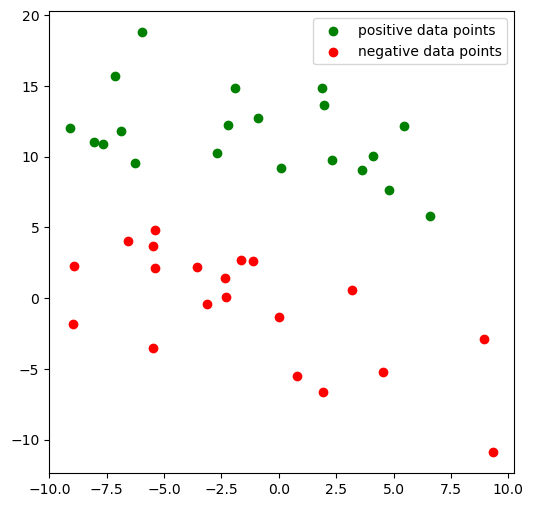

In [8]:
number_of_samples = 40
vertical_noise = 10
positive_labelled_data = [] 
negative_labelled_data = [] 

for _ in range(number_of_samples):
    is_this_pt_positive = True if random.random() >= 0.5 else False
    x_coord = random.uniform(-10,10)
    y_coord = random.uniform(0,vertical_noise)+(-0.5*x_coord+6) if is_this_pt_positive \
                  else random.uniform(-vertical_noise,0)+(-0.5*x_coord+3)
    if is_this_pt_positive:
        positive_labelled_data.append((x_coord,y_coord))
    else:
        negative_labelled_data.append((x_coord,y_coord))

plt.figure(figsize=(6,6))
plt.scatter(*zip(*positive_labelled_data),color='green',label='positive data points')
plt.scatter(*zip(*negative_labelled_data),color='red',label='negative data points')
plt.legend()
plt.show()

## Visualising $r_\theta$ for $\theta \in [0,2\pi)$

Now, we find $r_\theta := \min\{\alpha_i : y_i = +1\} - \max\{\alpha_i : y_i = -1\}$ for $\theta$ between $0$ and $2\pi$, and plot it so we can visualise how $r_\theta$ changes. As we mentioned, we should expect the optimal theta to occur when $\theta \approx 63.43^\circ$.

In [11]:
theta_values = np.linspace(0,1,36000)*2*np.pi #intervals are of size ~0.01 degree.
r_thetas = dict()

def r_theta(theta, pos_data, neg_data, return_details=False):    
    positively_labelled_alphas = [np.cos(theta)*x1 + np.sin(theta)*x2 for (x1,x2) in pos_data]    
    negatively_labelled_alphas = [np.cos(theta)*x1 + np.sin(theta)*x2 for (x1,x2) in neg_data]
    r_theta = min(positively_labelled_alphas) - max(negatively_labelled_alphas)
    if not return_details:
        return r_theta 
    return r_theta, min(positively_labelled_alphas), max(negatively_labelled_alphas)

for theta in theta_values: 
    r_thetas[theta] = r_theta(theta, positive_labelled_data, negative_labelled_data)

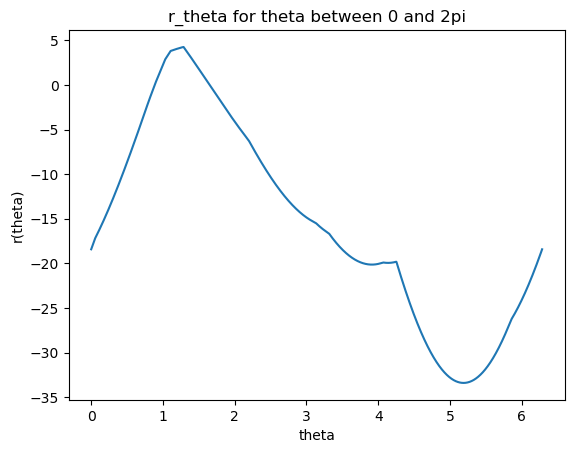

In [12]:
plt.plot(r_thetas.keys(), r_thetas.values())
plt.xlabel("theta")
plt.ylabel("r(theta)")
plt.title("r_theta for theta between 0 and 2pi")
plt.show()

## Maximising $r_\theta$, finding the optimal $\theta$, and computing $C$.

We now maximise the function `r_theta` to obtain optimal $(\theta, r_\theta)$, as well as $\min\{\alpha_i : y_i = +1\}$ and $\max\{\alpha_i : y_i = -1\}$ (with the latter two being returned via passing `return_details=True` to `r_theta`. 

Recall that $C$ is given by $C = \frac{1}{2}(\min\{\alpha_i : y_i = +1\} + \max\{\alpha_i : y_i = -1\})$, and that the optimal plane is given by $\langle \mathbf{x}, w_\theta \rangle = x_1\cos(\theta) + x_2\sin(\theta) = C$.

In [35]:
optimal_theta = max(r_thetas, key=lambda key: r_thetas[key])
r_value, min_positive_alphas, max_negative_alphas = r_theta(optimal_theta, positive_labelled_data, negative_labelled_data, return_details=True)

C = 0.5*(min_positive_alphas + max_negative_alphas)

print(f"The optimal theta is approximately {round(optimal_theta,2)} radians, or approximately {round(optimal_theta * 180/np.pi,2)} degrees.")
print(f"The value of C is approximately {round(C,2)}.")

The optimal theta is approximately 1.29 radians, or approximately 73.71 degrees.
The value of C is approximately 5.27.


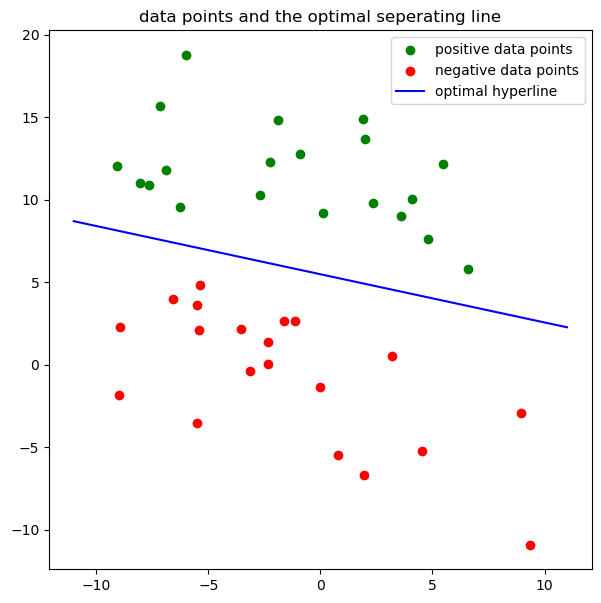

In [37]:
plt.figure(figsize=(7,7))
plt.scatter(*zip(*positive_labelled_data),color='green',label='positive data points')
plt.scatter(*zip(*negative_labelled_data),color='red',label='negative data points')

is_sin_theta_zero = (optimal_theta == 0)

if is_sin_theta_zero:
    #if sin(theta) = 0, then cos(theta) = 1, and x1cos(theta) + x2sin(theta) = C <=> x1 = C
    plt.axvline(C, color='blue', label = "optimal hyperline")
else:
    #sin(theta) != 0, and x2 = (C - x1cos(theta)) / sin(theta)
    x_vals = np.linspace(-11,11,1000)
    y_vals = (C - x_vals*np.cos(optimal_theta))/np.sin(optimal_theta)
    plt.plot(x_vals,y_vals, color='blue', label = "optimal hyperline")

plt.title("data points and the optimal seperating line")
plt.legend()
plt.show()